# 🔬 Carbon-24 GMM Clustering - Complete Analysis

**Gaussian Mixture Model (GMM)** - Phân cụm xác suất với phân tích chi tiết

**Dataset:** 10,153 cấu trúc Carbon-24

**Nội dung:**
1. Load dữ liệu và chuẩn bị
2. Chạy GMM và chọn số clusters tối ưu (AIC/BIC)
3. Kết quả phân cụm cụ thể
4. Trực quan hóa PCA 3D
5. Phân tích uncertainty
6. Export kết quả

In [12]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import plotly.graph_objects as go
import plotly.express as px
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print(' Libraries imported successfully!')

 Libraries imported successfully!


##  1. Load Data & Preparation

In [13]:
# Load feature data
print(' Loading feature data...')
df = pd.read_csv('carbon24_feature_selected/carbon24_feature_selected_standard.csv')

with open('carbon24_feature_selected/selected_features.json', 'r') as f:
    feature_info = json.load(f)

# Get numeric features (exclude relative_energy for clustering)
numeric_features = [f for f in feature_info['numeric_features'] 
                   if f != 'relative_energy' and f in df.columns]

print(f' Loaded data: {df.shape}')
print(f'   Features for clustering: {len(numeric_features)}')
print(f'   Features: {numeric_features[:5]}...')

# Prepare data for clustering
X = df[numeric_features].values
print(f'\n Data shape: {X.shape}')

 Loading feature data...
 Loaded data: (10153, 31)
   Features for clustering: 21
   Features: ['num_atoms', 'a', 'b', 'c', 'alpha']...

 Data shape: (10153, 21)


##  2. GMM Model Selection (AIC/BIC)

In [14]:
# Run GMM for n_components from 2 to 10
print(' Training GMM models from 2 to 10 components...')

n_components_range = range(2, 11)
aic_scores = []
bic_scores = []
models = {}

for n in n_components_range:
    print(f'  Training GMM with n={n}...', end=' ')
    gmm = GaussianMixture(n_components=n, covariance_type='full', 
                          random_state=42, max_iter=200)
    gmm.fit(X)
    
    aic = gmm.aic(X)
    bic = gmm.bic(X)
    
    aic_scores.append(aic)
    bic_scores.append(bic)
    models[n] = gmm
    
    print(f'AIC={aic:.0f}, BIC={bic:.0f}')

print('\n Model training complete!')

# Find optimal n_components
optimal_n_aic = n_components_range[np.argmin(aic_scores)]
optimal_n_bic = n_components_range[np.argmin(bic_scores)]

print(f'\n Optimal n_components:')
print(f'   By AIC: {optimal_n_aic}')
print(f'   By BIC: {optimal_n_bic}')

 Training GMM models from 2 to 10 components...
  Training GMM with n=2... AIC=-55625, BIC=-51977
  Training GMM with n=3... AIC=-436245, BIC=-430769
  Training GMM with n=4... AIC=-524896, BIC=-517591
  Training GMM with n=5... AIC=-525914, BIC=-516781
  Training GMM with n=6... AIC=-589428, BIC=-578467
  Training GMM with n=7... AIC=-619481, BIC=-606692
  Training GMM with n=8... AIC=-617566, BIC=-602948
  Training GMM with n=9... AIC=-646190, BIC=-629745
  Training GMM with n=10... AIC=-656300, BIC=-638027

 Model training complete!

 Optimal n_components:
   By AIC: 10
   By BIC: 10


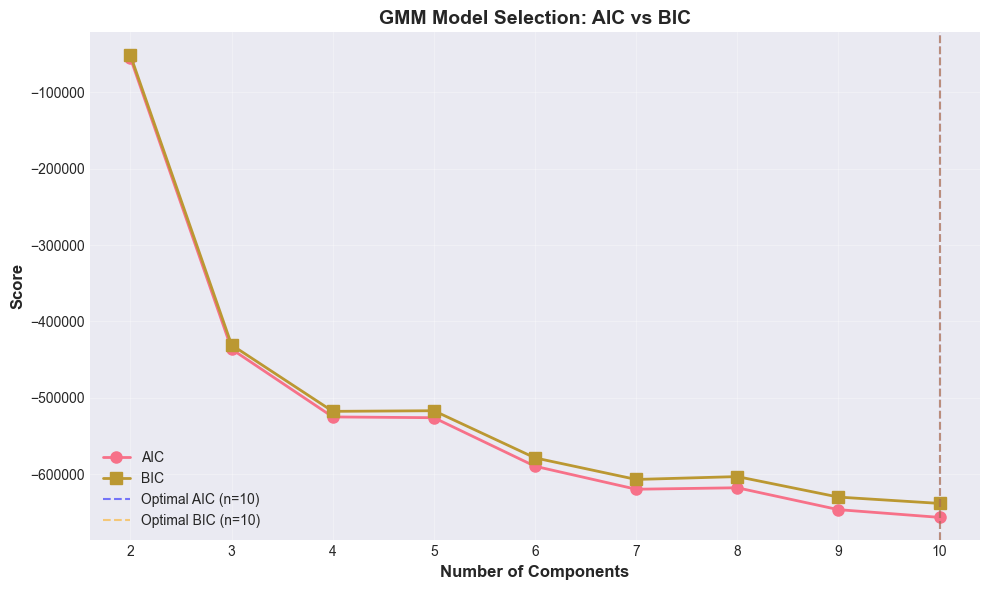

 AIC/BIC visualization complete!


In [15]:
# Visualize AIC/BIC scores
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(n_components_range, aic_scores, 'o-', label='AIC', linewidth=2, markersize=8)
ax.plot(n_components_range, bic_scores, 's-', label='BIC', linewidth=2, markersize=8)

ax.axvline(optimal_n_aic, color='blue', linestyle='--', alpha=0.5, label=f'Optimal AIC (n={optimal_n_aic})')
ax.axvline(optimal_n_bic, color='orange', linestyle='--', alpha=0.5, label=f'Optimal BIC (n={optimal_n_bic})')

ax.set_xlabel('Number of Components', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('GMM Model Selection: AIC vs BIC', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(' AIC/BIC visualization complete!')

##  3. Clustering Results with Best Model

In [16]:
# Use BIC optimal model (usually more conservative)
optimal_n = optimal_n_bic
best_gmm = models[optimal_n]

print(f' Using GMM with {optimal_n} components (BIC optimal)')

# Predict clusters and probabilities
cluster_labels = best_gmm.predict(X)
cluster_probs = best_gmm.predict_proba(X)
max_probs = cluster_probs.max(axis=1)

# Add to dataframe
df['GMM_Cluster'] = cluster_labels
df['Max_Probability'] = max_probs
df['Is_Uncertain'] = max_probs < 0.7  # Uncertain if max prob < 0.7

print(f'\n Clustering complete!')
print(f'   Total samples: {len(df):,}')
print(f'   Number of clusters: {optimal_n}')
print(f'   Uncertain samples (prob < 0.7): {df["Is_Uncertain"].sum():,} ({df["Is_Uncertain"].sum()/len(df)*100:.2f}%)')

 Using GMM with 10 components (BIC optimal)

 Clustering complete!
   Total samples: 10,153
   Number of clusters: 10
   Uncertain samples (prob < 0.7): 49 (0.48%)


 CLUSTER DISTRIBUTION (Phân bố các clusters)

Cluster 0:
  Số lượng mẫu: 955 (9.41%)
  Năng lượng trung bình: 0.6926 ± 0.4633 eV/atom
  Xác suất trung bình: 0.9946

Cluster 1:
  Số lượng mẫu: 194 (1.91%)
  Năng lượng trung bình: 0.7062 ± 0.3179 eV/atom
  Xác suất trung bình: 0.9966

Cluster 2:
  Số lượng mẫu: 847 (8.34%)
  Năng lượng trung bình: -1.4813 ± 0.1115 eV/atom
  Xác suất trung bình: 1.0000

Cluster 3:
  Số lượng mẫu: 3,226 (31.77%)
  Năng lượng trung bình: 0.4778 ± 0.5371 eV/atom
  Xác suất trung bình: 0.9965

Cluster 4:
  Số lượng mẫu: 823 (8.11%)
  Năng lượng trung bình: 0.1812 ± 0.8681 eV/atom
  Xác suất trung bình: 1.0000

Cluster 5:
  Số lượng mẫu: 24 (0.24%)
  Năng lượng trung bình: 1.0722 ± 0.2597 eV/atom
  Xác suất trung bình: 1.0000

Cluster 6:
  Số lượng mẫu: 1,096 (10.79%)
  Năng lượng trung bình: -0.2609 ± 0.8981 eV/atom
  Xác suất trung bình: 0.9906

Cluster 7:
  Số lượng mẫu: 35 (0.34%)
  Năng lượng trung bình: 0.9919 ± 0.3139 eV/atom
  Xác suất trung bình: 1.00

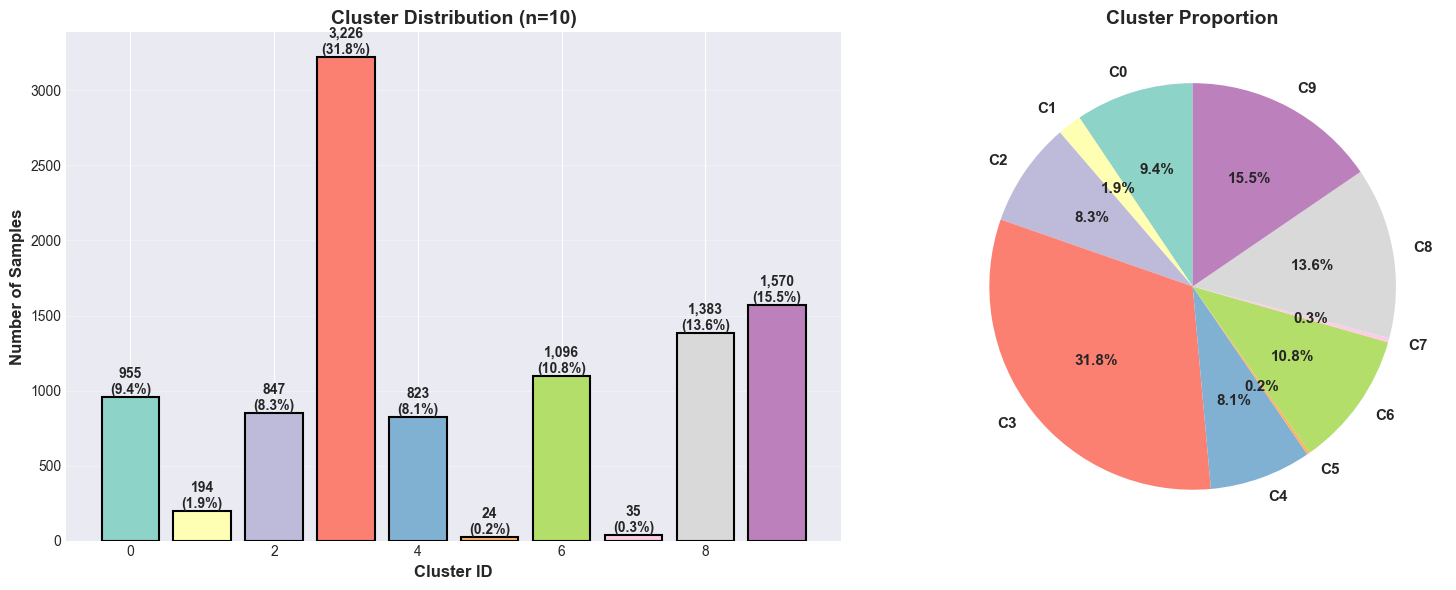


 Cluster distribution visualization complete!


In [17]:
#  CLUSTER DISTRIBUTION - Kết quả phân cụm cụ thể
print('=' * 80)
print(' CLUSTER DISTRIBUTION (Phân bố các clusters)')
print('=' * 80)

cluster_counts = df['GMM_Cluster'].value_counts().sort_index()

for cluster_id, count in cluster_counts.items():
    percentage = count / len(df) * 100
    print(f'\nCluster {cluster_id}:')
    print(f'  Số lượng mẫu: {count:,} ({percentage:.2f}%)')
    
    # Energy statistics for this cluster
    cluster_data = df[df['GMM_Cluster'] == cluster_id]
    mean_energy = cluster_data['relative_energy'].mean()
    std_energy = cluster_data['relative_energy'].std()
    
    print(f'  Năng lượng trung bình: {mean_energy:.4f} ± {std_energy:.4f} eV/atom')
    print(f'  Xác suất trung bình: {cluster_data["Max_Probability"].mean():.4f}')

print('\n' + '=' * 80)

# Visualize cluster distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
ax = axes[0]
bars = ax.bar(cluster_counts.index, cluster_counts.values, 
              color=plt.cm.Set3(range(len(cluster_counts))), 
              edgecolor='black', linewidth=1.5)
ax.set_xlabel('Cluster ID', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title(f'Cluster Distribution (n={optimal_n})', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, cluster_counts.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{int(val):,}\n({val/len(df)*100:.1f}%)',
           ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
ax = axes[1]
colors = plt.cm.Set3(range(len(cluster_counts)))
wedges, texts, autotexts = ax.pie(cluster_counts.values, 
                                    labels=[f'C{i}' for i in cluster_counts.index],
                                    colors=colors,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title('Cluster Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n Cluster distribution visualization complete!')

## 4. PCA  Visualization

Trực quan hóa kết quả phân cụm trong không gian 3 chiều sử dụng PCA

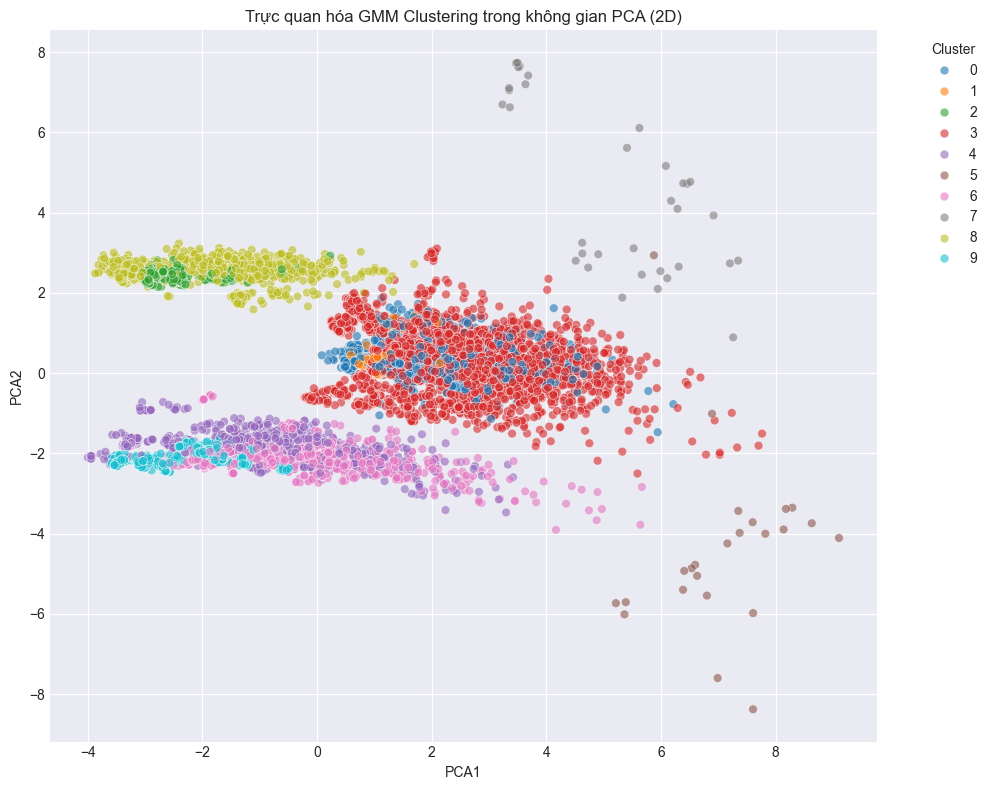

In [26]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='GMM_Cluster',
    palette='tab10',
    data=df,
    alpha=0.6,
    s=40
)
plt.title('Trực quan hóa GMM Clustering trong không gian PCA (2D)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

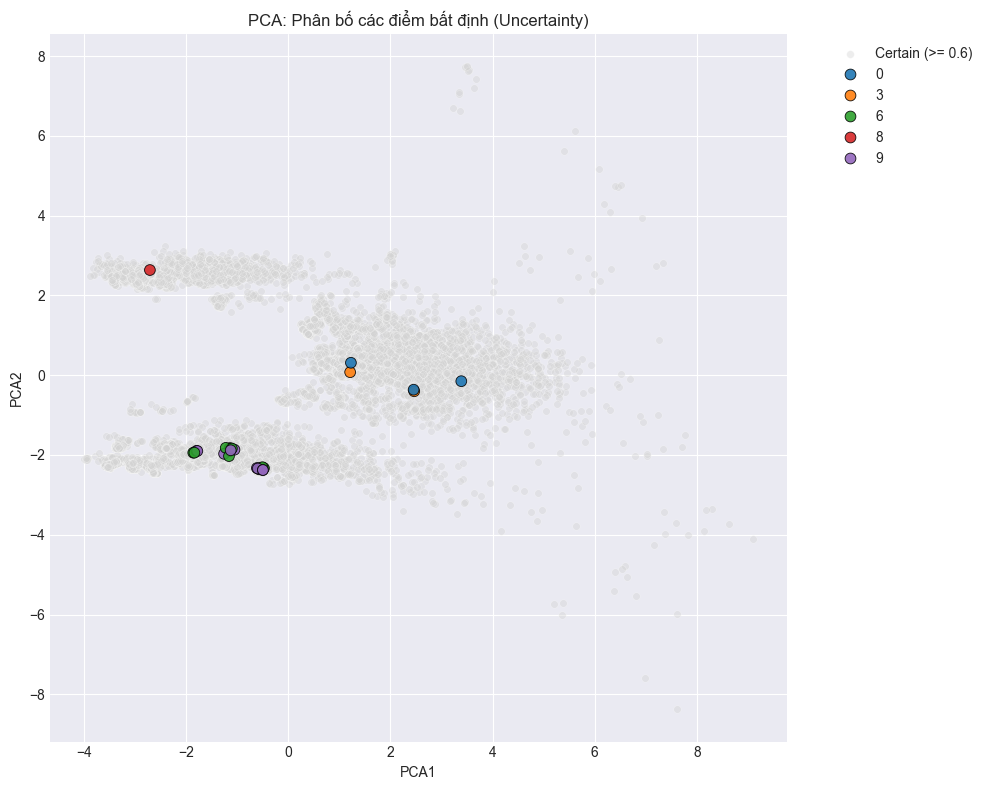

In [27]:
df['Is_Uncertain'] = df['Max_Probability'] < threshold

plt.figure(figsize=(10, 8))

# Vẽ các điểm Certain (nhạt màu)
sns.scatterplot(
    x='PCA1', y='PCA2',
    color='lightgray',
    data=df[~df['Is_Uncertain']],
    alpha=0.4,
    s=30,
    label=f'Certain (>= {threshold})'
)

# Vẽ các điểm Uncertain (màu nổi bật)
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='GMM_Cluster',  # Tô màu theo cụm dự đoán để xem điểm nhiễu thuộc về vùng nào
    palette='tab10',
    data=df[df['Is_Uncertain']],
    alpha=0.9,
    s=60,
    edgecolor='black'
)
plt.title('PCA: Phân bố các điểm bất định (Uncertainty)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [18]:
# Perform PCA for 3D visualization
print(' Performing PCA for 3D visualization...')

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X)

# Add PCA components to dataframe
df['PCA1'] = X_pca_3d[:, 0]
df['PCA2'] = X_pca_3d[:, 1]
df['PCA3'] = X_pca_3d[:, 2]

explained_var = pca_3d.explained_variance_ratio_
print(f'\n PCA complete!')
print(f'   PC1 explains: {explained_var[0]*100:.2f}% variance')
print(f'   PC2 explains: {explained_var[1]*100:.2f}% variance')
print(f'   PC3 explains: {explained_var[2]*100:.2f}% variance')
print(f'   Total: {sum(explained_var)*100:.2f}% variance explained')

 Performing PCA for 3D visualization...

 PCA complete!
   PC1 explains: 23.99% variance
   PC2 explains: 16.09% variance
   PC3 explains: 10.26% variance
   Total: 50.34% variance explained


 Creating interactive 3D visualization...


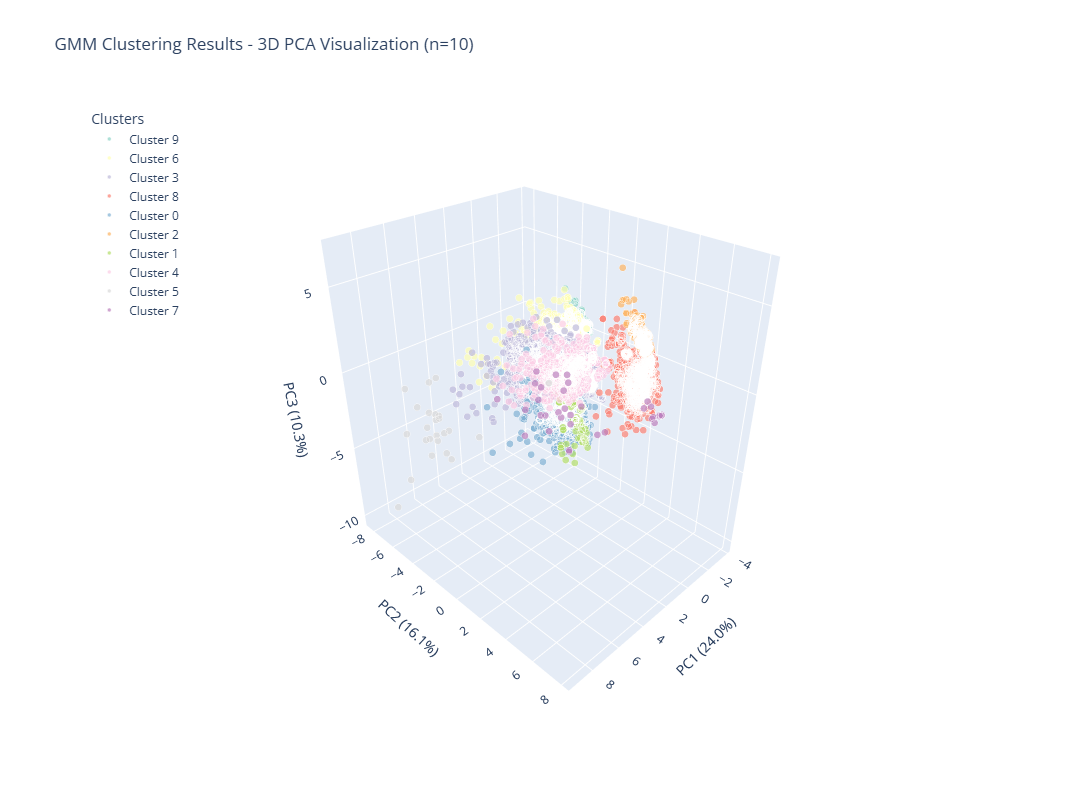


 Interactive 3D visualization created!
    Tip: Rotate, zoom, and hover over points to explore the clusters


In [19]:
# Create interactive 3D scatter plot with Plotly
print(' Creating interactive 3D visualization...')

# Prepare data for plotting
plot_df = df[['PCA1', 'PCA2', 'PCA3', 'GMM_Cluster', 'Max_Probability', 
              'relative_energy', 'material_id']].copy()
plot_df['Cluster'] = 'Cluster ' + plot_df['GMM_Cluster'].astype(str)

# Create 3D scatter plot
fig = px.scatter_3d(
    plot_df,
    x='PCA1',
    y='PCA2',
    z='PCA3',
    color='Cluster',
    hover_data={
        'PCA1': ':.3f',
        'PCA2': ':.3f',
        'PCA3': ':.3f',
        'Max_Probability': ':.3f',
        'relative_energy': ':.4f',
        'material_id': True,
        'Cluster': True
    },
    title=f'GMM Clustering Results - 3D PCA Visualization (n={optimal_n})',
    labels={
        'PCA1': f'PC1 ({explained_var[0]*100:.1f}%)',
        'PCA2': f'PC2 ({explained_var[1]*100:.1f}%)',
        'PCA3': f'PC3 ({explained_var[2]*100:.1f}%)'
    },
    color_discrete_sequence=px.colors.qualitative.Set3
)

# Update layout
fig.update_layout(
    width=1000,
    height=800,
    font=dict(size=12),
    scene=dict(
        xaxis_title=f'PC1 ({explained_var[0]*100:.1f}%)',
        yaxis_title=f'PC2 ({explained_var[1]*100:.1f}%)',
        zaxis_title=f'PC3 ({explained_var[2]*100:.1f}%)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.3)
        )
    ),
    legend=dict(
        title='Clusters',
        yanchor='top',
        y=0.99,
        xanchor='left',
        x=0.01
    )
)

# Update markers
fig.update_traces(
    marker=dict(
        size=4,
        opacity=0.7,
        line=dict(width=0.5, color='white')
    )
)

fig.show()

print('\n Interactive 3D visualization created!')
print('    Tip: Rotate, zoom, and hover over points to explore the clusters')

 Creating 3D visualization colored by energy...


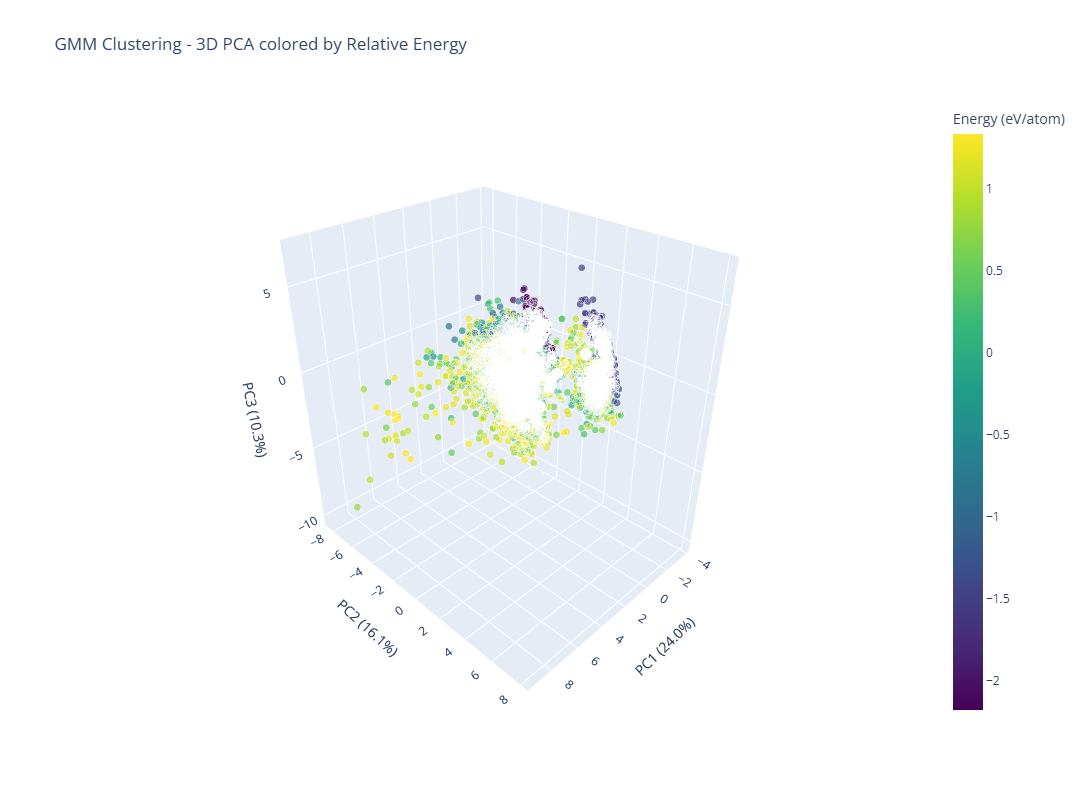


 Energy-colored 3D visualization created!


In [20]:
# Create 3D scatter colored by energy
print(' Creating 3D visualization colored by energy...')

fig = px.scatter_3d(
    plot_df,
    x='PCA1',
    y='PCA2',
    z='PCA3',
    color='relative_energy',
    hover_data={
        'PCA1': ':.3f',
        'PCA2': ':.3f',
        'PCA3': ':.3f',
        'Max_Probability': ':.3f',
        'relative_energy': ':.4f',
        'material_id': True,
        'Cluster': True
    },
    title='GMM Clustering - 3D PCA colored by Relative Energy',
    labels={
        'PCA1': f'PC1 ({explained_var[0]*100:.1f}%)',
        'PCA2': f'PC2 ({explained_var[1]*100:.1f}%)',
        'PCA3': f'PC3 ({explained_var[2]*100:.1f}%)',
        'relative_energy': 'Energy (eV/atom)'
    },
    color_continuous_scale='Viridis'
)

fig.update_layout(
    width=1000,
    height=800,
    font=dict(size=12),
    scene=dict(
        xaxis_title=f'PC1 ({explained_var[0]*100:.1f}%)',
        yaxis_title=f'PC2 ({explained_var[1]*100:.1f}%)',
        zaxis_title=f'PC3 ({explained_var[2]*100:.1f}%)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.3)
        )
    )
)

fig.update_traces(
    marker=dict(
        size=4,
        opacity=0.7,
        line=dict(width=0.5, color='white')
    )
)

fig.show()

print('\n Energy-colored 3D visualization created!')

## 5. Clustering Quality Metrics

In [22]:
# Calculate clustering quality metrics
print(' Calculating clustering quality metrics...')

# Sample for faster computation if needed
if len(X) > 5000:
    sample_idx = np.random.choice(len(X), 5000, replace=False)
    X_sample = X[sample_idx]
    labels_sample = cluster_labels[sample_idx]
    print(f'   Using sample of 5000 points for Silhouette Score')
else:
    X_sample = X
    labels_sample = cluster_labels

silhouette = silhouette_score(X_sample, labels_sample)
davies_bouldin = davies_bouldin_score(X, cluster_labels)
calinski = calinski_harabasz_score(X, cluster_labels)

print('\n' + '=' * 80)
print(' CLUSTERING QUALITY METRICS')
print('=' * 80)
print(f'\nSilhouette Score:      {silhouette:.4f}  (↑ higher is better, range: [-1, 1])')
print(f'Davies-Bouldin Index:  {davies_bouldin:.4f}  (↓ lower is better, range: [0, ∞))')
print(f'Calinski-Harabasz:     {calinski:.2f}  (↑ higher is better, range: [0, ∞))')
print('\n' + '=' * 80)

# Interpretation
print('\n Interpretation:')
if silhouette > 0.5:
    print('    Silhouette Score: Good cluster separation')
elif silhouette > 0.25:
    print('     Silhouette Score: Weak cluster separation')
else:
    print('    Silhouette Score: Poor cluster separation')

if davies_bouldin < 1.0:
    print('    Davies-Bouldin: Good cluster compactness')
else:
    print('     Davies-Bouldin: Acceptable cluster compactness')

if calinski > 1000:
    print('    Calinski-Harabasz: Excellent cluster definition')
elif calinski > 100:
    print('    Calinski-Harabasz: Good cluster definition')
else:
    print('     Calinski-Harabasz: Acceptable cluster definition')

 Calculating clustering quality metrics...
   Using sample of 5000 points for Silhouette Score

 CLUSTERING QUALITY METRICS

Silhouette Score:      0.0971  (↑ higher is better, range: [-1, 1])
Davies-Bouldin Index:  1.9730  (↓ lower is better, range: [0, ∞))
Calinski-Harabasz:     1103.31  (↑ higher is better, range: [0, ∞))


 Interpretation:
    Silhouette Score: Poor cluster separation
     Davies-Bouldin: Acceptable cluster compactness
    Calinski-Harabasz: Excellent cluster definition


##  6. Uncertainty Analysis

Phân tích các mẫu có xác suất phân cụm thấp (uncertain samples)

 UNCERTAINTY ANALYSIS

Total samples: 10,153
Certain samples (prob ≥ 0.7): 10,104 (99.52%)
Uncertain samples (prob < 0.7): 49 (0.48%)


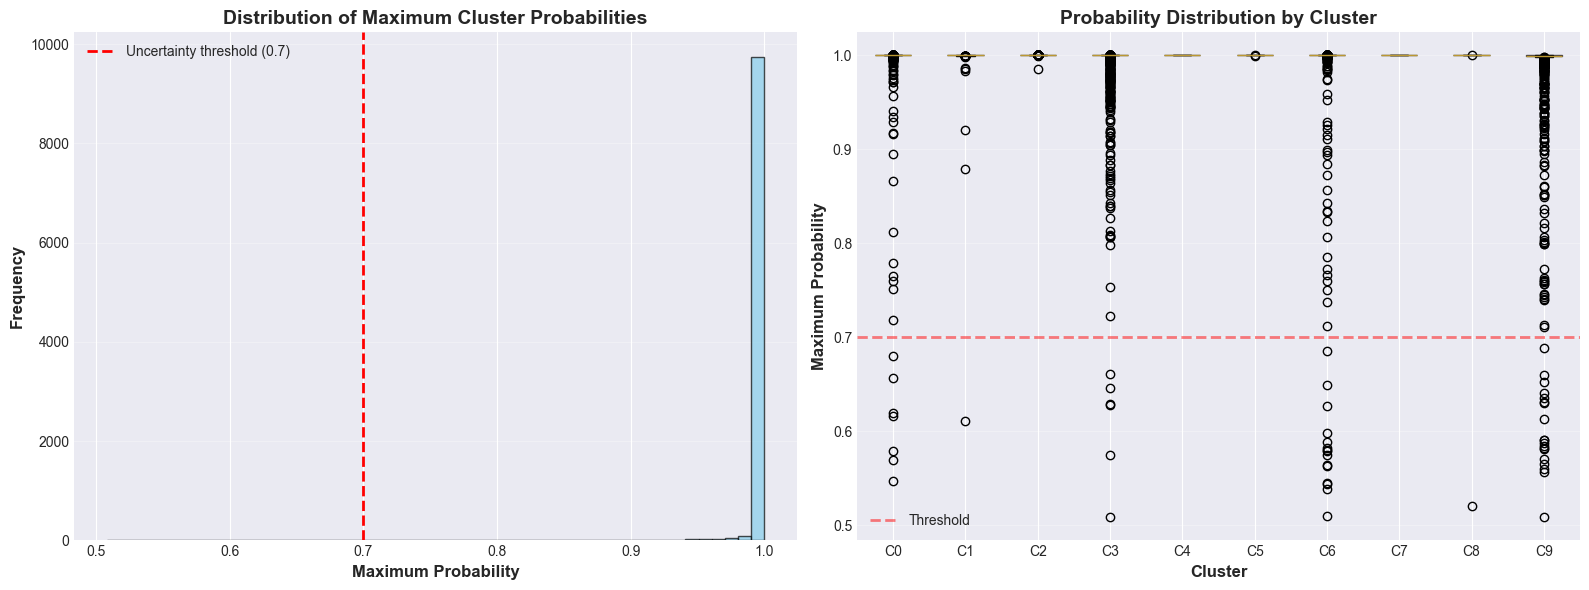


 Uncertainty analysis complete!


In [23]:
# Analyze uncertain samples
print('=' * 80)
print(' UNCERTAINTY ANALYSIS')
print('=' * 80)

uncertain_samples = df[df['Is_Uncertain']]
certain_samples = df[~df['Is_Uncertain']]

print(f'\nTotal samples: {len(df):,}')
print(f'Certain samples (prob ≥ 0.7): {len(certain_samples):,} ({len(certain_samples)/len(df)*100:.2f}%)')
print(f'Uncertain samples (prob < 0.7): {len(uncertain_samples):,} ({len(uncertain_samples)/len(df)*100:.2f}%)')

# Probability distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of max probabilities
ax = axes[0]
ax.hist(df['Max_Probability'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax.axvline(0.7, color='red', linestyle='--', linewidth=2, label='Uncertainty threshold (0.7)')
ax.set_xlabel('Maximum Probability', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Maximum Cluster Probabilities', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Boxplot by cluster
ax = axes[1]
cluster_probs = [df[df['GMM_Cluster'] == i]['Max_Probability'].values 
                 for i in sorted(df['GMM_Cluster'].unique())]
bp = ax.boxplot(cluster_probs, labels=[f'C{i}' for i in sorted(df['GMM_Cluster'].unique())],
                patch_artist=True)

# Color boxes
colors = plt.cm.Set3(range(len(cluster_probs)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(0.7, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Threshold')
ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax.set_ylabel('Maximum Probability', fontsize=12, fontweight='bold')
ax.set_title('Probability Distribution by Cluster', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n Uncertainty analysis complete!')

## 7. Cluster Profiles

Phân tích đặc điểm của từng cluster

In [24]:
# Create cluster profile table
print('=' * 80)
print(' CLUSTER PROFILES')
print('=' * 80)

cluster_profiles = []

for cluster_id in sorted(df['GMM_Cluster'].unique()):
    cluster_data = df[df['GMM_Cluster'] == cluster_id]
    
    profile = {
        'Cluster': cluster_id,
        'Count': len(cluster_data),
        'Percentage': f"{len(cluster_data)/len(df)*100:.2f}%",
        'Mean_Energy': cluster_data['relative_energy'].mean(),
        'Std_Energy': cluster_data['relative_energy'].std(),
        'Mean_Probability': cluster_data['Max_Probability'].mean(),
        'Uncertain_Count': cluster_data['Is_Uncertain'].sum(),
        'Uncertain_Pct': f"{cluster_data['Is_Uncertain'].sum()/len(cluster_data)*100:.2f}%"
    }
    
    cluster_profiles.append(profile)

profile_df = pd.DataFrame(cluster_profiles)

print('\n')
print(profile_df.to_string(index=False))
print('\n' + '=' * 80)

# Find most stable cluster
most_stable_cluster = profile_df.loc[profile_df['Mean_Energy'].idxmin(), 'Cluster']
print(f'\n Most stable cluster: Cluster {most_stable_cluster}')
print(f'   Mean energy: {profile_df.loc[profile_df["Cluster"] == most_stable_cluster, "Mean_Energy"].values[0]:.4f} eV/atom')

print('\n Cluster profiling complete!')

 CLUSTER PROFILES


 Cluster  Count Percentage  Mean_Energy  Std_Energy  Mean_Probability  Uncertain_Count Uncertain_Pct
       0    955      9.41%     0.692570    0.463251          0.994639                7         0.73%
       1    194      1.91%     0.706171    0.317876          0.996628                1         0.52%
       2    847      8.34%    -1.481323    0.111499          0.999983                0         0.00%
       3   3226     31.77%     0.477809    0.537076          0.996501                6         0.19%
       4    823      8.11%     0.181189    0.868137          1.000000                0         0.00%
       5     24      0.24%     1.072209    0.259681          0.999995                0         0.00%
       6   1096     10.79%    -0.260899    0.898119          0.990626               15         1.37%
       7     35      0.34%     0.991950    0.313936          1.000000                0         0.00%
       8   1383     13.62%     0.300347    0.963866          0.999653  

##  8. Export Results

In [25]:
# Export results
output_dir = 'carbon24_gmm_results'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(f'{output_dir}/results', exist_ok=True)
os.makedirs(f'{output_dir}/tables', exist_ok=True)
os.makedirs(f'{output_dir}/figures', exist_ok=True)

print(' Exporting results...')

# 1. Save clustered data
output_file = f'{output_dir}/results/carbon24_gmm_results.csv'
df.to_csv(output_file, index=False)
print(f' Saved: {output_file}')

# 2. Save cluster profile
profile_file = f'{output_dir}/tables/gmm_cluster_profile.csv'
profile_df.to_csv(profile_file, index=False)
print(f' Saved: {profile_file}')

# 3. Save uncertain samples
uncertain_file = f'{output_dir}/tables/gmm_uncertain_samples.csv'
uncertain_samples.to_csv(uncertain_file, index=False)
print(f' Saved: {uncertain_file}')

# 4. Save clustering report
report = {
    'optimal_n_components': int(optimal_n),
    'n_samples': len(df),
    'n_features': len(numeric_features),
    'metrics': {
        'silhouette_score': float(silhouette),
        'davies_bouldin_index': float(davies_bouldin),
        'calinski_harabasz_score': float(calinski),
        'aic': float(aic_scores[optimal_n - 2]),
        'bic': float(bic_scores[optimal_n - 2])
    },
    'cluster_distribution': {
        int(k): int(v) for k, v in cluster_counts.items()
    },
    'uncertainty': {
        'total_uncertain': int(len(uncertain_samples)),
        'uncertain_percentage': float(len(uncertain_samples)/len(df)*100)
    },
    'pca_variance_explained': {
        'pc1': float(explained_var[0]),
        'pc2': float(explained_var[1]),
        'pc3': float(explained_var[2]),
        'total': float(sum(explained_var))
    }
}

report_file = f'{output_dir}/gmm_clustering_report.json'
with open(report_file, 'w') as f:
    json.dump(report, f, indent=2)
print(f' Saved: {report_file}')

print('\n' + '=' * 80)
print(' ALL RESULTS EXPORTED SUCCESSFULLY!')
print('=' * 80)
print(f'\n Output directory: {output_dir}/')
print(f'   - results/carbon24_gmm_results.csv')
print(f'   - tables/gmm_cluster_profile.csv')
print(f'   - tables/gmm_uncertain_samples.csv')
print(f'   - gmm_clustering_report.json')

 Exporting results...
 Saved: carbon24_gmm_results/results/carbon24_gmm_results.csv
 Saved: carbon24_gmm_results/tables/gmm_cluster_profile.csv
 Saved: carbon24_gmm_results/tables/gmm_uncertain_samples.csv
 Saved: carbon24_gmm_results/gmm_clustering_report.json

 ALL RESULTS EXPORTED SUCCESSFULLY!

 Output directory: carbon24_gmm_results/
   - results/carbon24_gmm_results.csv
   - tables/gmm_cluster_profile.csv
   - tables/gmm_uncertain_samples.csv
   - gmm_clustering_report.json


##  Summary

###  Completed Tasks:

1. **Model Selection**: Chọn số clusters tối ưu bằng AIC/BIC
2. **Clustering**: Phân cụm {optimal_n} clusters với GMM
3. **Kết quả cụ thể**: Hiển thị số lượng mẫu trong mỗi cluster
4. **PCA 3D Visualization**: Trực quan hóa tương tác 3D
5. **Quality Metrics**: Đánh giá chất lượng phân cụm
6. **Uncertainty Analysis**: Phân tích mẫu không chắc chắn
7. **Cluster Profiles**: Đặc điểm của từng cluster
8. **Export**: Lưu tất cả kết quả

###  Key Findings:

- **Optimal clusters**: {optimal_n} (selected by BIC)
- **Total samples**: {len(df):,}
- **Uncertain samples**: {len(uncertain_samples):,} ({len(uncertain_samples)/len(df)*100:.2f}%)
- **Most stable cluster**: Cluster {most_stable_cluster}

###  Next Steps:

1. So sánh với các phương pháp khác (K-means, Hierarchical, HDBSCAN)
2. Phân tích stability và energy prediction
3. Sử dụng kết quả cho material discovery

**Notebook hoàn thành! **